# Classification ML Project

## Data Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('healthcare_classification_practice_dataset.csv')
df.head()

,patient_id,age,gender,region,year,month,bmi,blood_pressure,cholesterol,glucose,...,exercise_hours,stress_level,smoking_status,alcohol_consumption,monthly_analyses,biomarker_abnormal_rate,avg_metabolic_risk,avg_cardiovascular_risk,health_score,disease_risk
0,1,56,Male,South,2024,9,30.095595,106.501574,206.581260,80.988882,...,2.914920,7.332494,Current,0.293863,11556,0.098861,24.744334,91.559032,93.890668,Medium
1,2,69,Male,West,2022,2,29.450703,99.965231,224.305816,65.776427,...,3.153404,2.457050,Current,1.126622,13674,0.190832,21.376878,94.645677,91.379635,Medium
2,3,46,Male,Central,2023,9,41.011043,122.370804,231.382817,80.765972,...,2.982920,4.492626,NaN,3.655749,6501,0.214824,27.639997,79.637918,98.514433,Low
3,4,32,Female,South,2025,2,35.921488,131.358421,242.972629,106.886951,...,0.997600,4.171071,Current,0.663766,5896,0.444533,17.033714,88.996633,87.242810,Medium
4,5,60,Male,South,2024,1,31.126982,110.044925,NaN,97.672673,...,3.686458,4.881695,Never,1.210030,3963,0.138635,48.195633,77.482551,91.434713,Low


In [3]:
df.tail()

,patient_id,age,gender,region,year,month,bmi,blood_pressure,cholesterol,glucose,...,exercise_hours,stress_level,smoking_status,alcohol_consumption,monthly_analyses,biomarker_abnormal_rate,avg_metabolic_risk,avg_cardiovascular_risk,health_score,disease_risk
11995,11996,20,Male,NaN,2024,8,26.589581,NaN,197.830072,101.197070,...,2.017053,8.306505,NaN,6.505086,2490,0.115296,45.360592,73.317820,88.436848,Low
11996,11997,37,Female,South,2023,3,22.328594,103.784992,188.642497,60.000000,...,4.115023,5.228416,Never,2.279420,2422,0.346379,21.749437,74.829405,91.124782,Low
11997,11998,23,Female,North,2025,4,25.180276,122.179990,183.172317,90.719014,...,9.115208,NaN,Never,1.534425,5086,0.220868,24.803285,79.479280,96.756074,Low
11998,11999,56,Male,NaN,2022,12,31.956060,104.983915,224.139867,113.534162,...,2.619923,6.432433,Former,0.649329,7450,0.381778,32.532646,79.058998,94.748424,Medium
11999,12000,50,Male,West,2023,6,NaN,107.147434,191.095858,120.783173,...,3.086899,6.481477,NaN,0.054906,12841,0.045297,46.515096,88.589645,93.747148,Low


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               12000 non-null  int64  
 1   age                      12000 non-null  int64  
 2   gender                   12000 non-null  object 
 3   region                   10693 non-null  object 
 4   year                     12000 non-null  int64  
 5   month                    12000 non-null  int64  
 6   bmi                      11138 non-null  float64
 7   blood_pressure           10794 non-null  float64
 8   cholesterol              11369 non-null  float64
 9   glucose                  11162 non-null  float64
 10  heart_rate               12000 non-null  float64
 11  oxygen_level             11393 non-null  float64
 12  sleep_hours              10621 non-null  float64
 13  exercise_hours           10747 non-null  float64
 14  stress_level          

In [5]:
df.describe()

,patient_id,age,year,month,bmi,blood_pressure,cholesterol,glucose,heart_rate,oxygen_level,sleep_hours,exercise_hours,stress_level,alcohol_consumption,monthly_analyses,biomarker_abnormal_rate,avg_metabolic_risk,avg_cardiovascular_risk,health_score
count,12000.00000,12000.000000,12000.000000,12000.000000,11138.000000,10794.000000,11369.000000,11162.000000,12000.000000,11393.000000,10621.000000,10747.000000,11136.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,6000.50000,49.223667,2023.753667,6.463083,27.068572,112.397576,202.258532,100.527091,72.036086,96.911939,7.014508,2.980494,5.021888,2.992721,7571.188917,0.286431,36.058159,79.695387,91.326504
std,3464.24595,18.185018,1.041990,3.424439,4.962812,11.660233,30.615152,23.818288,11.984982,1.886787,1.486300,2.910509,1.982038,2.972017,4278.856782,0.160050,10.065929,12.681393,4.951377
min,1.00000,18.000000,2022.000000,1.000000,15.000000,80.000000,100.000000,60.000000,40.000000,89.915950,2.000000,0.000020,1.000000,0.000439,1057.000000,0.002676,1.409600,29.277032,74.558449
25%,3000.75000,34.000000,2023.000000,3.000000,23.592623,104.647913,182.367038,82.888793,63.969287,95.630699,6.019187,0.856849,3.600498,0.823816,4955.000000,0.161301,29.185346,71.153677,87.880553
50%,6000.50000,49.000000,2024.000000,6.000000,27.047449,112.417238,201.582765,100.367723,72.061071,96.985510,7.016486,2.057762,5.004732,2.080095,6671.000000,0.266067,36.020062,79.665289,91.249739
75%,9000.25000,65.000000,2025.000000,9.000000,30.450824,120.219556,221.391513,116.866259,80.171856,98.292130,8.014865,4.129347,6.394326,4.152127,9118.250000,0.390143,42.805692,88.327118,94.852864
max,12000.00000,80.000000,2025.000000,12.000000,44.351834,153.545460,426.779572,202.508557,114.216454,100.000000,12.000000,15.000000,10.000000,20.000000,92945.000000,0.850449,76.866644,127.394857,100.000000


In [6]:
df.shape

(12000, 23)

In [7]:
df.dtypes

patient_id                   int64
age                          int64
gender                      object
region                      object
year                         int64
month                        int64
bmi                        float64
blood_pressure             float64
cholesterol                float64
glucose                    float64
heart_rate                 float64
oxygen_level               float64
sleep_hours                float64
exercise_hours             float64
stress_level               float64
smoking_status              object
alcohol_consumption        float64
monthly_analyses             int64
biomarker_abnormal_rate    float64
avg_metabolic_risk         float64
avg_cardiovascular_risk    float64
health_score               float64
disease_risk                object
dtype: object

## Exploratory Data Analysis(EDA)

In [8]:
df.isnull().sum()

patient_id                    0
age                           0
gender                        0
region                     1307
year                          0
month                         0
bmi                         862
blood_pressure             1206
cholesterol                 631
glucose                     838
heart_rate                    0
oxygen_level                607
sleep_hours                1379
exercise_hours             1253
stress_level                864
smoking_status             1571
alcohol_consumption           0
monthly_analyses              0
biomarker_abnormal_rate       0
avg_metabolic_risk            0
avg_cardiovascular_risk       0
health_score                  0
disease_risk                  0
dtype: int64

In [9]:
missing_percentage = df.isnull().mean() * 100
print(missing_percentage)

patient_id                  0.000000
age                         0.000000
gender                      0.000000
region                     10.891667
year                        0.000000
month                       0.000000
bmi                         7.183333
blood_pressure             10.050000
cholesterol                 5.258333
glucose                     6.983333
heart_rate                  0.000000
oxygen_level                5.058333
sleep_hours                11.491667
exercise_hours             10.441667
stress_level                7.200000
smoking_status             13.091667
alcohol_consumption         0.000000
monthly_analyses            0.000000
biomarker_abnormal_rate     0.000000
avg_metabolic_risk          0.000000
avg_cardiovascular_risk     0.000000
health_score                0.000000
disease_risk                0.000000
dtype: float64


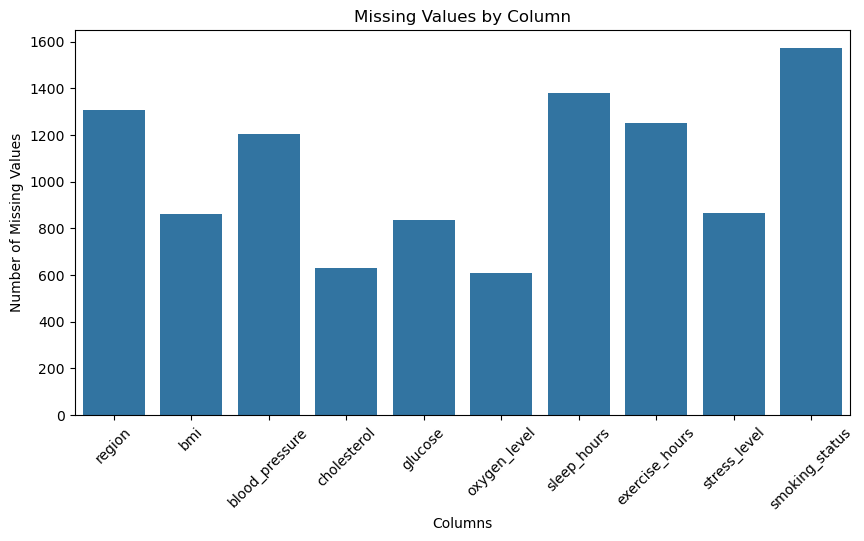

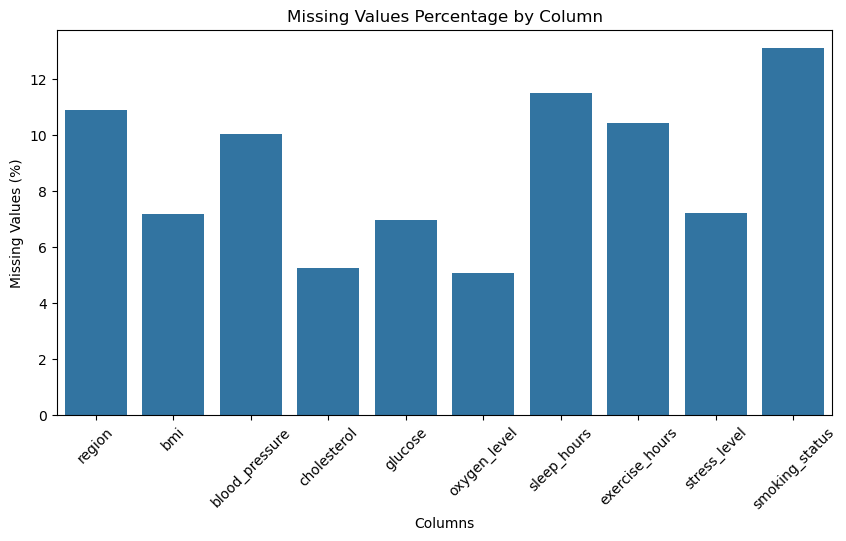

In [10]:
missing = df.isnull().sum()

missing = missing[missing > 0]

plt.figure(figsize=(10, 5))

sns.barplot(
    x=missing.index,
    y=missing.values
)

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")

plt.xticks(rotation=45)
plt.show()

missing_percentage = df.isnull().mean() * 100

missing_percentage = missing_percentage[
    missing_percentage > 0
]

plt.figure(figsize=(10, 5))

sns.barplot(
    x=missing_percentage.index,
    y=missing_percentage.values
)

plt.title("Missing Values Percentage by Column")
plt.xlabel("Columns")
plt.ylabel("Missing Values (%)")

plt.xticks(rotation=45)
plt.show()

In [11]:
df[df.duplicated()]

,patient_id,age,gender,region,year,month,bmi,blood_pressure,cholesterol,glucose,...,exercise_hours,stress_level,smoking_status,alcohol_consumption,monthly_analyses,biomarker_abnormal_rate,avg_metabolic_risk,avg_cardiovascular_risk,health_score,disease_risk


In [12]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
print(numeric_cols)

['patient_id', 'age', 'year', 'month', 'bmi', 'blood_pressure', 'cholesterol', 'glucose', 'heart_rate', 'oxygen_level', 'sleep_hours', 'exercise_hours', 'stress_level', 'alcohol_consumption', 'monthly_analyses', 'biomarker_abnormal_rate', 'avg_metabolic_risk', 'avg_cardiovascular_risk', 'health_score']


In [13]:
from scipy.stats import zscore

numeric_columns = [
     'bmi', 'blood_pressure', 'cholesterol', 'glucose', 'heart_rate', 'oxygen_level', 
    'sleep_hours', 'exercise_hours', 'stress_level', 'alcohol_consumption', 'monthly_analyses',
    'biomarker_abnormal_rate', 'avg_metabolic_risk', 'avg_cardiovascular_risk', 'health_score']

for col in numeric_columns:
    z_scores = zscore(df[col].dropna())
    outliers = df[col].dropna()[abs(z_scores) > 3]
    print(f"{col}: {len(outliers)} outliers")

bmi: 10 outliers
blood_pressure: 14 outliers
cholesterol: 62 outliers
glucose: 26 outliers
heart_rate: 16 outliers
oxygen_level: 29 outliers
sleep_hours: 27 outliers
exercise_hours: 209 outliers
stress_level: 0 outliers
alcohol_consumption: 210 outliers
monthly_analyses: 156 outliers
biomarker_abnormal_rate: 29 outliers
avg_metabolic_risk: 32 outliers
avg_cardiovascular_risk: 36 outliers
health_score: 10 outliers


In [14]:
for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"{col}: {len(outliers)} outliers")

bmi: 24 outliers
blood_pressure: 84 outliers
cholesterol: 135 outliers
glucose: 38 outliers
heart_rate: 47 outliers
oxygen_level: 46 outliers
sleep_hours: 73 outliers
exercise_hours: 523 outliers
stress_level: 0 outliers
alcohol_consumption: 565 outliers
monthly_analyses: 464 outliers
biomarker_abnormal_rate: 65 outliers
avg_metabolic_risk: 72 outliers
avg_cardiovascular_risk: 82 outliers
health_score: 17 outliers


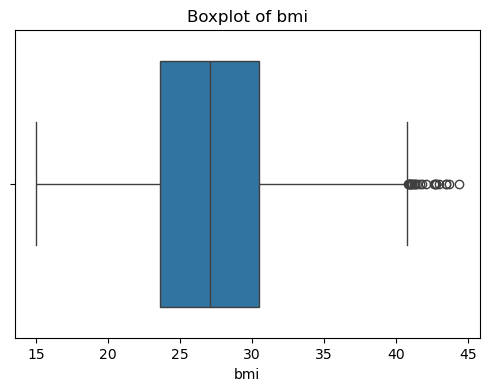

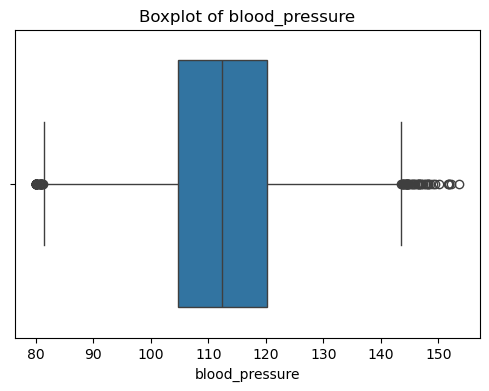

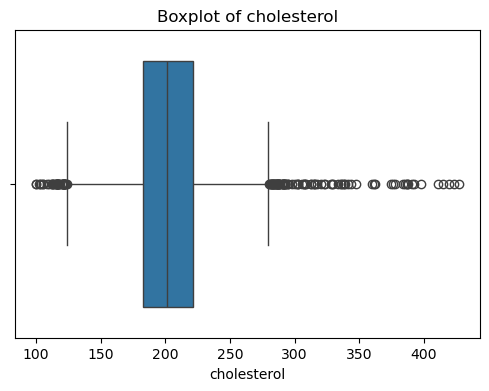

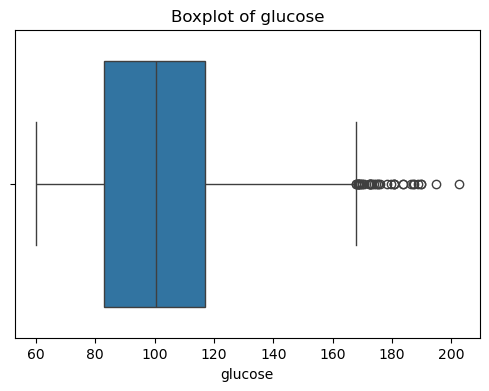

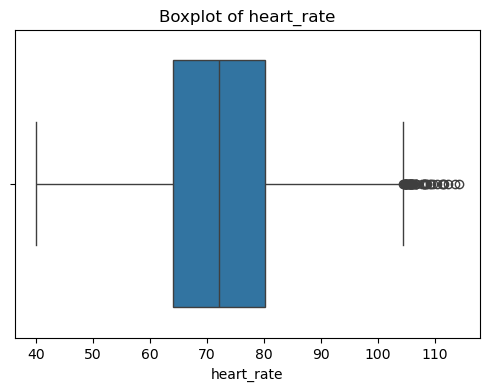

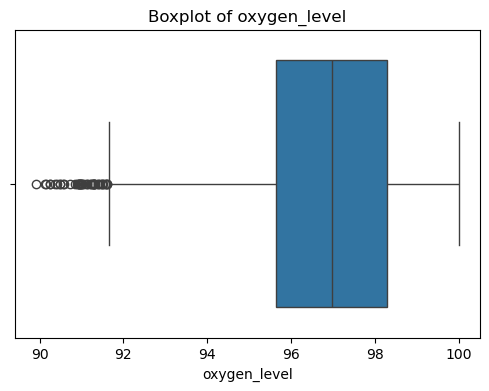

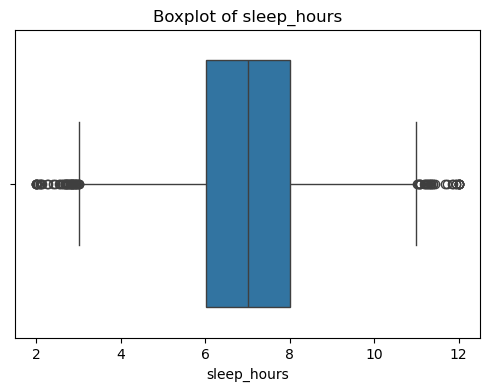

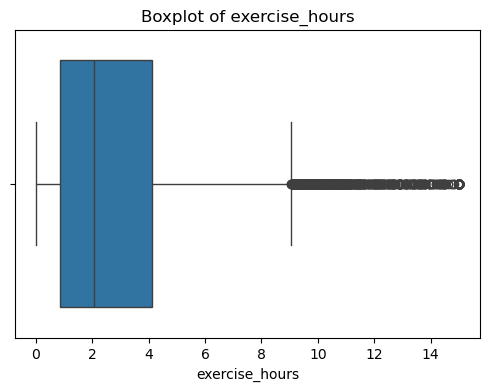

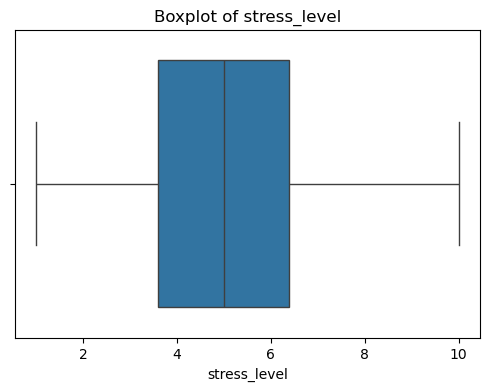

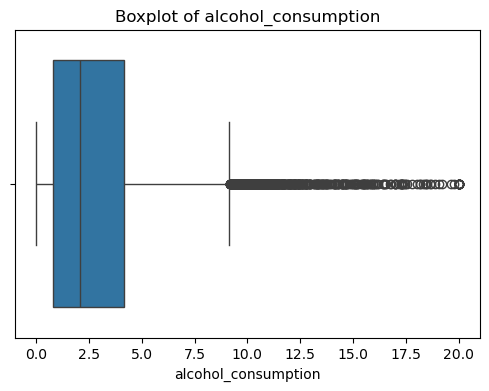

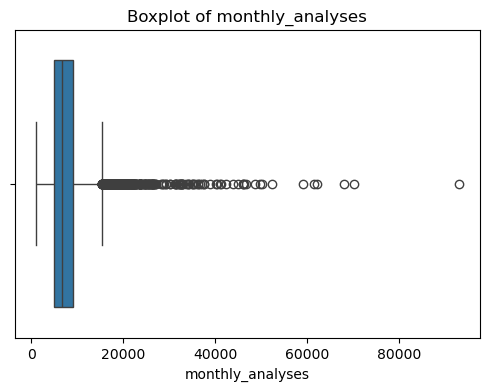

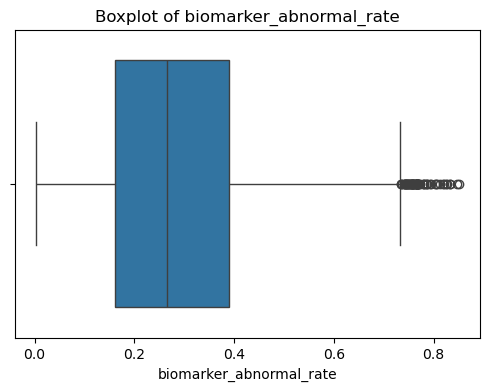

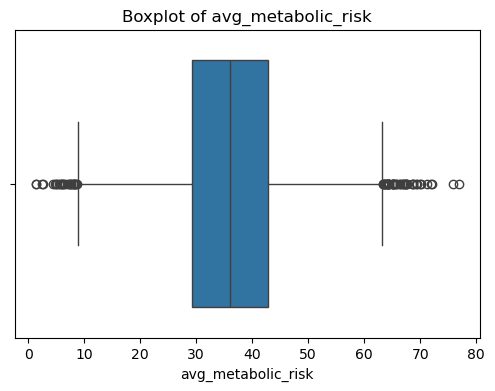

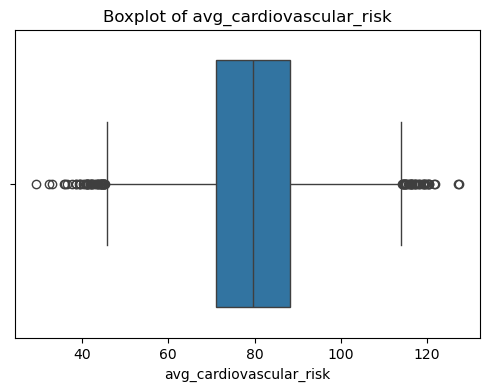

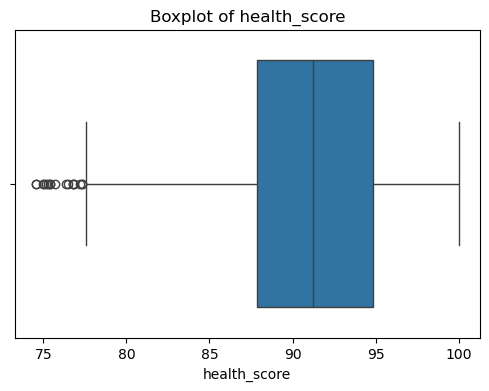

In [15]:
for col in numeric_columns:

    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")
    plt.show()

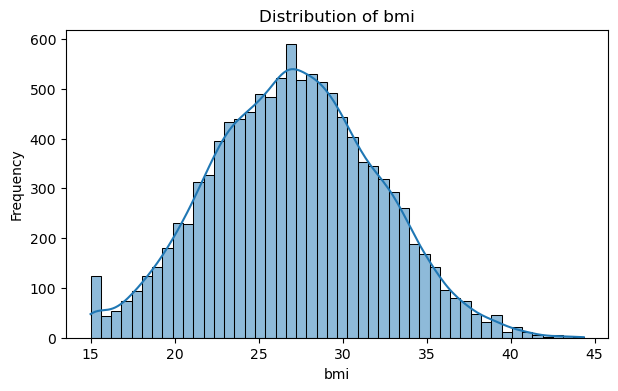

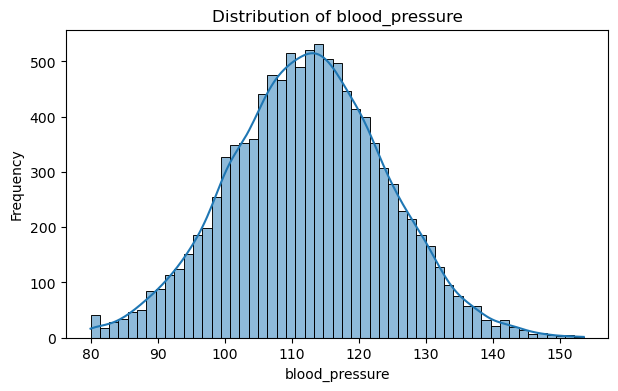

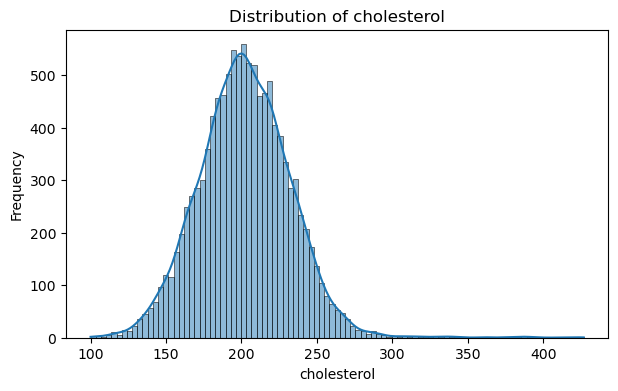

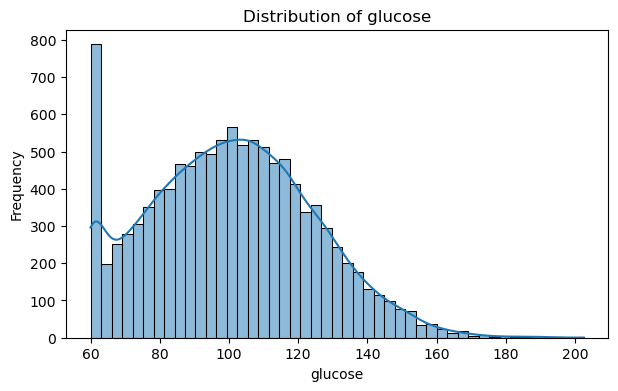

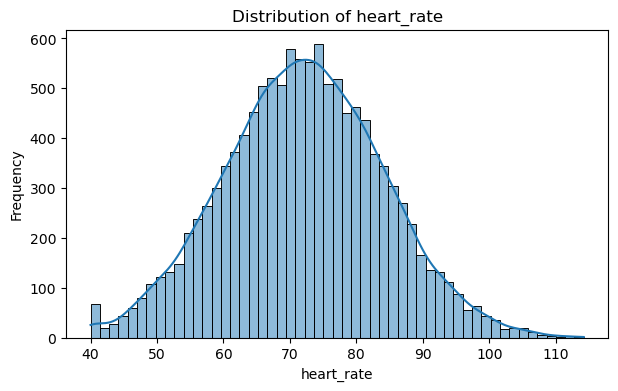

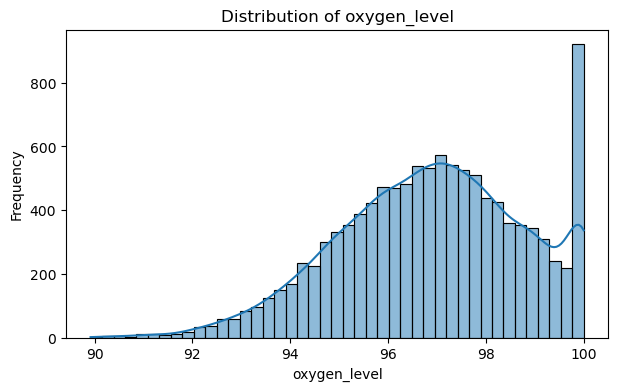

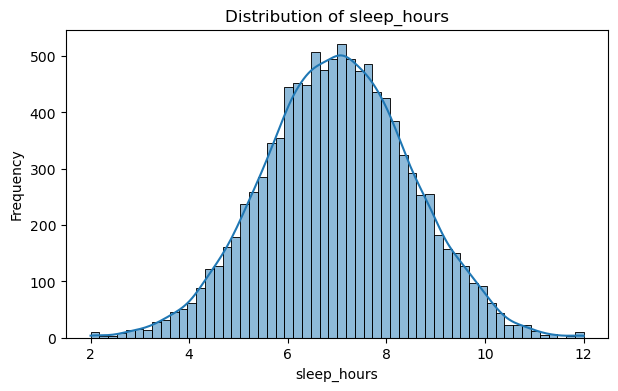

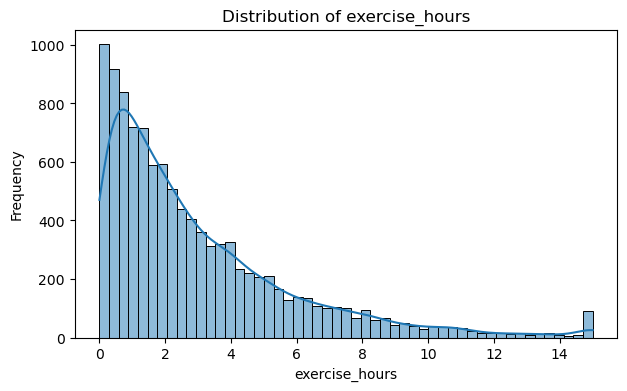

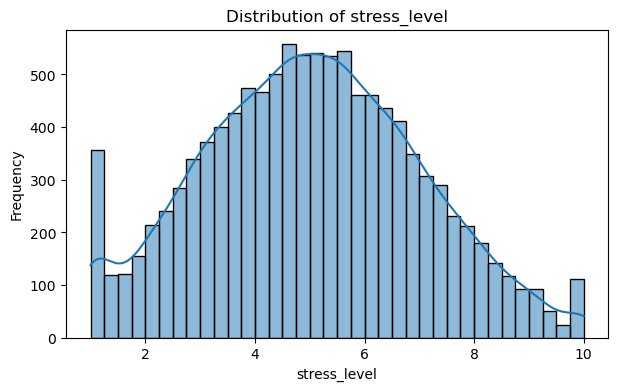

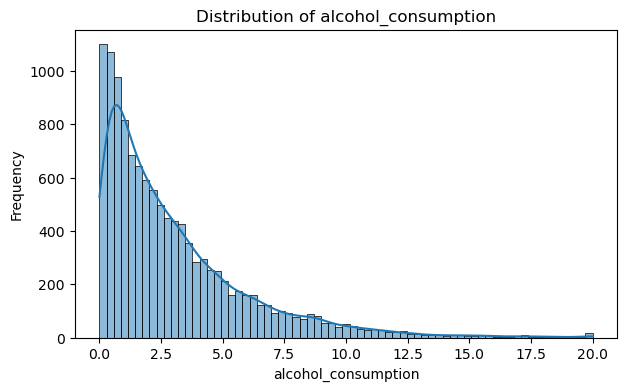

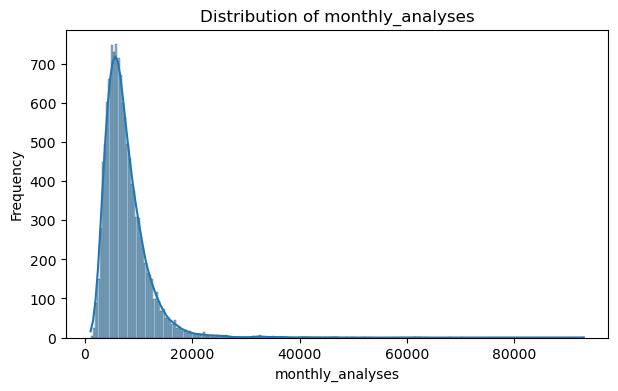

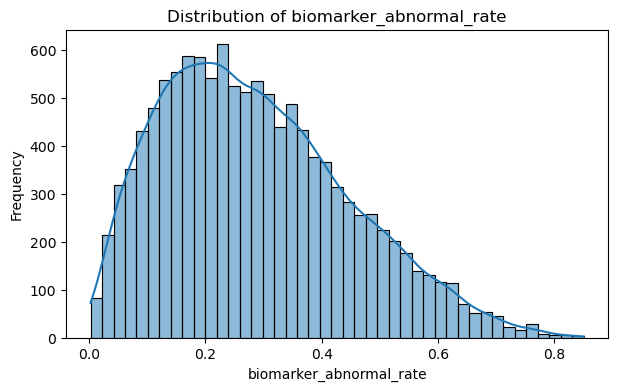

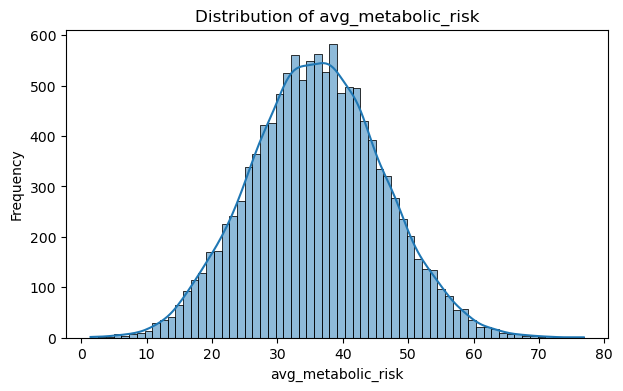

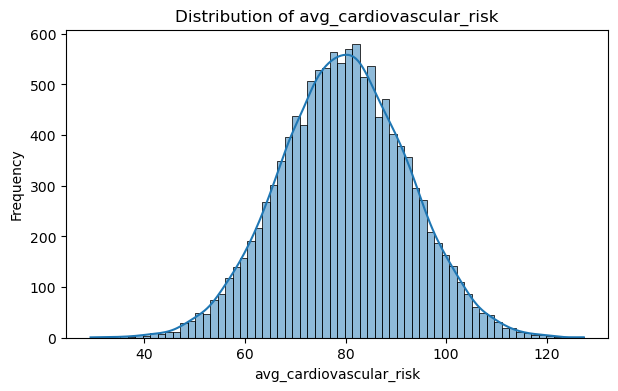

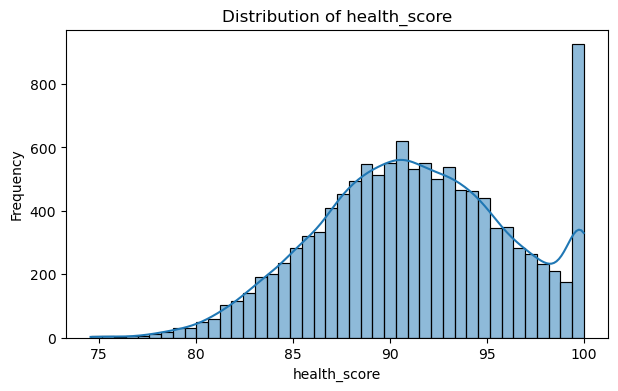

bmi                        0.039719
blood_pressure             0.017538
cholesterol                0.498807
glucose                    0.238191
heart_rate                 0.021673
oxygen_level              -0.292363
sleep_hours               -0.015289
exercise_hours             1.666965
stress_level               0.088627
alcohol_consumption        1.842305
monthly_analyses           3.960875
biomarker_abnormal_rate    0.561748
avg_metabolic_risk         0.062098
avg_cardiovascular_risk   -0.011192
health_score              -0.083873
dtype: float64


In [16]:
for col in numeric_columns:

    plt.figure(figsize=(7, 4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()
print(df[numeric_columns].skew())

| Skewness Category | Features |
|---|---|
| **Right-Skewed** | Cholesterol, Glucose, Exercise Hours, Alcohol Consumption, Monthly Analyses, Biomarker Abnormal Rate |
| **Left-Skewed** | Oxygen Level, Health Score |
| **Slightly Skewed / No Skewness** | Average Metabolic Risk, Average Cardiovascular Risk, Stress Level, Sleep Hours, Heart Rate, Blood Pressure, BMI |

In [17]:
categorical_cols = df.select_dtypes(include='object').columns
print(categorical_cols)

Index(['gender', 'region', 'smoking_status', 'disease_risk'], dtype='object')


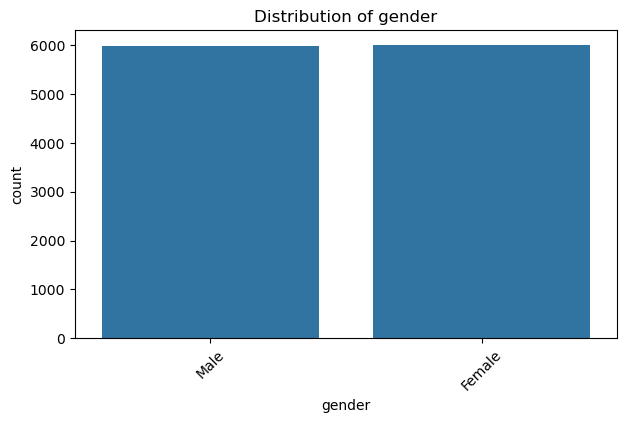

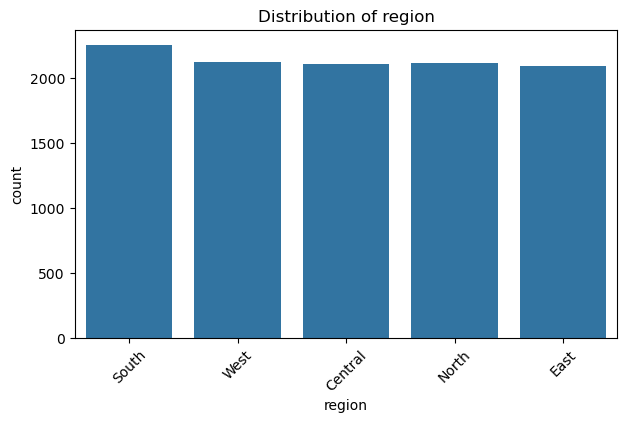

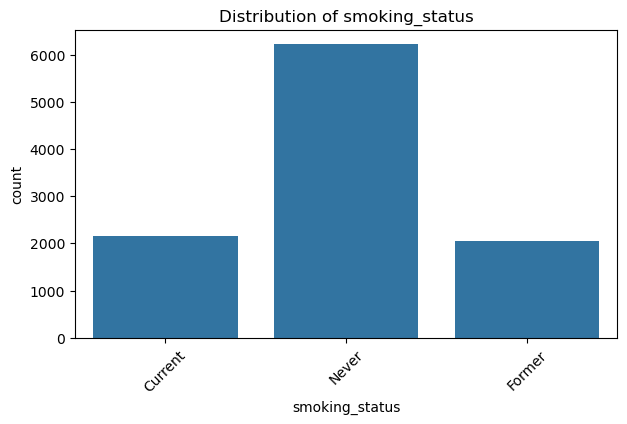

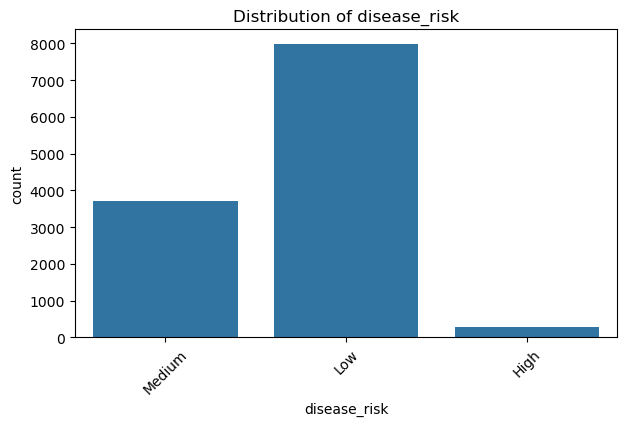

In [18]:
for col in categorical_cols:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()

Based on the categorical analysis, disease-risk distribution appears relatively similar across gender and region, suggesting a weak association. In contrast, smoking status shows noticeable differences in disease-risk distribution, suggesting a potential association between smoking status and disease risk.

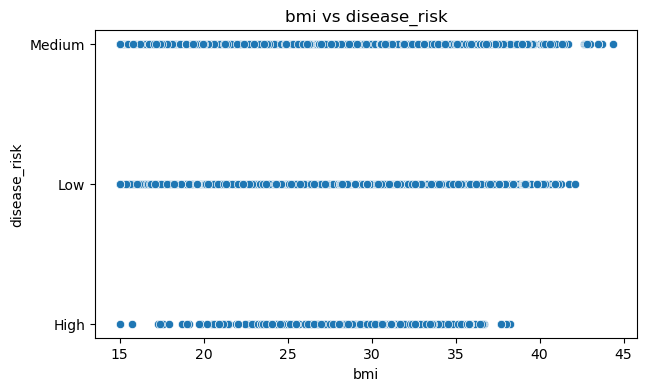

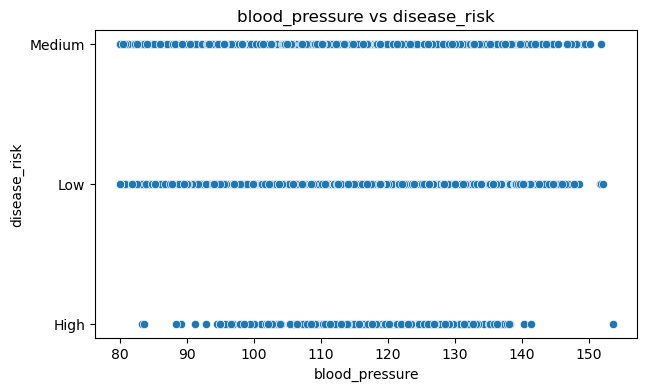

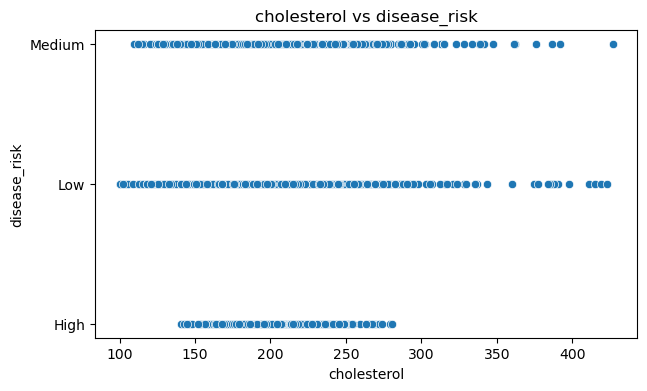

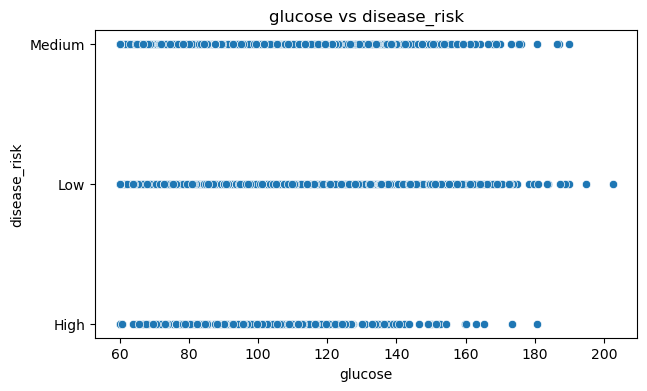

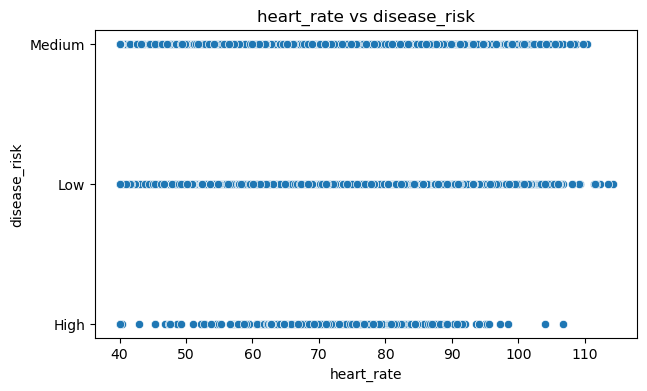

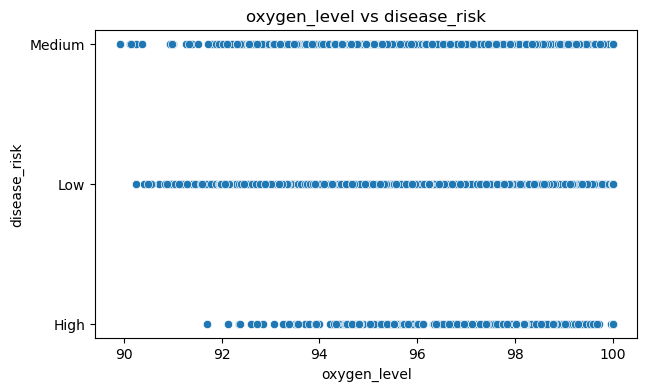

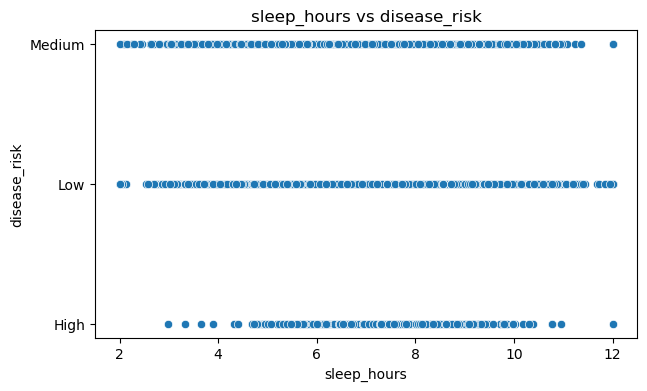

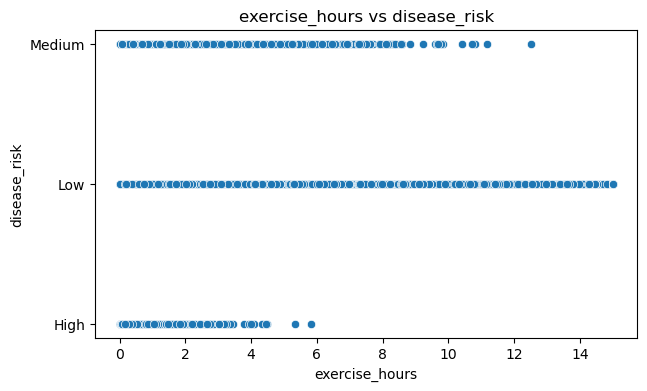

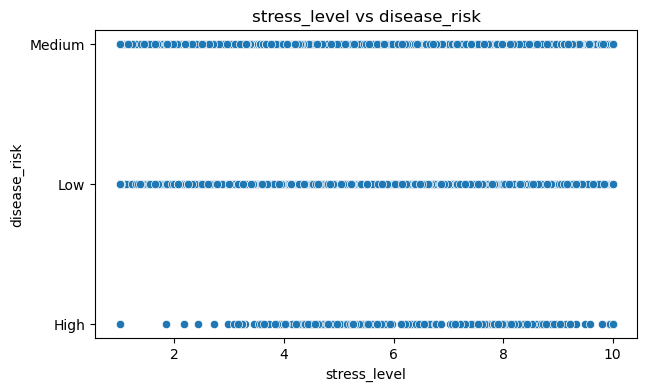

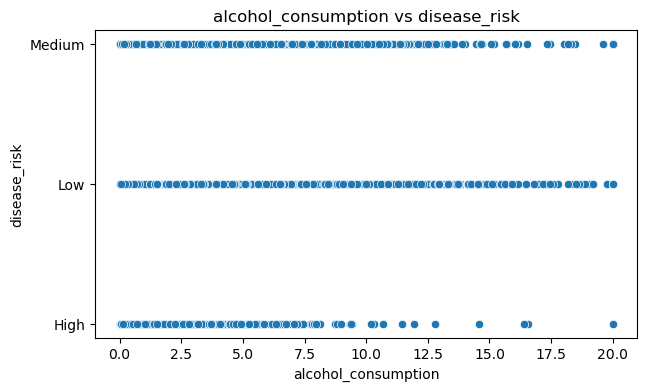

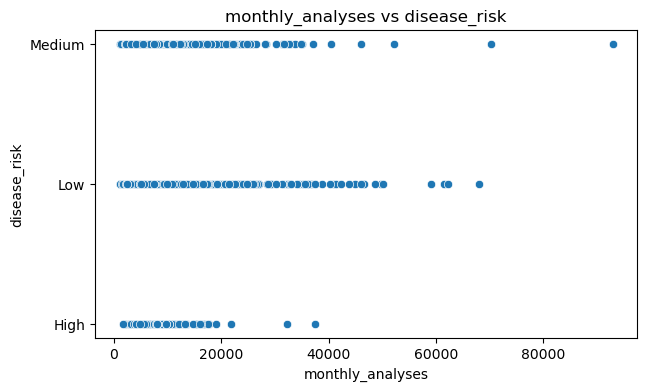

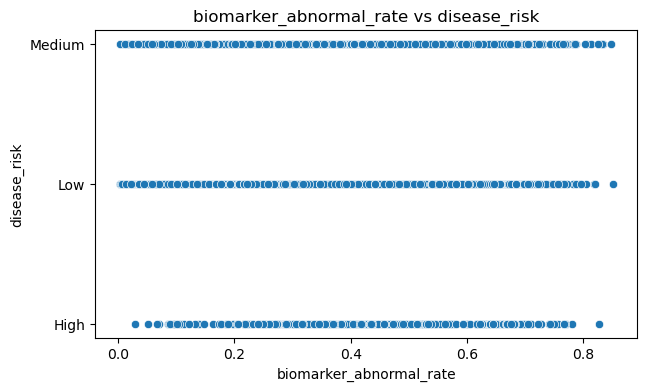

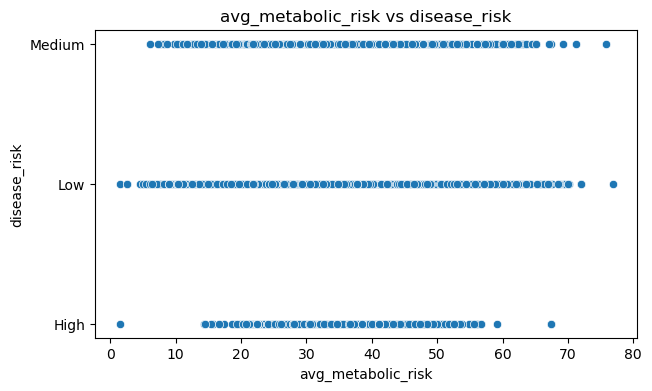

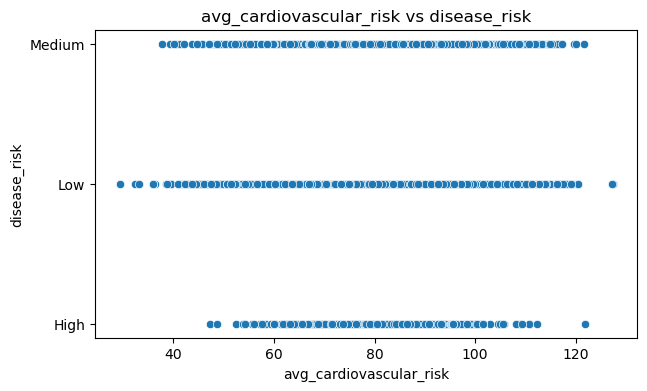

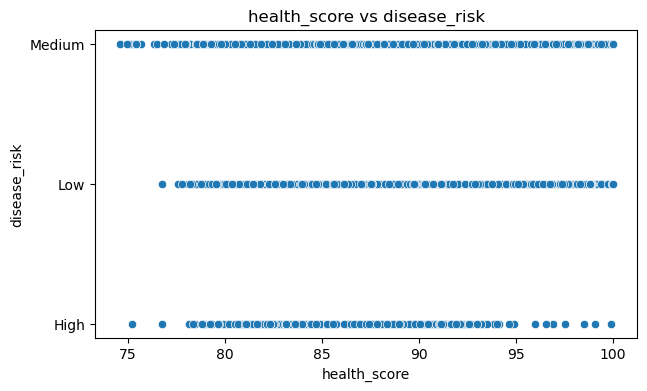

In [19]:
target = 'disease_risk'
feature_cols = [
    'age','bmi','blood_pressure','cholesterol','glucose','heart_rate',
    'oxygen_level','sleep_hours','exercise_hours','stress_level',
    'alcohol_consumption','monthly_analyses','biomarker_abnormal_rate',
    'avg_metabolic_risk','avg_cardiovascular_risk','health_score'
]

for col in numeric_columns:
    plt.figure(figsize=(7, 4))

    sns.scatterplot(
        data=df,
        x=col,
        y=target
    )

    plt.title(f'{col} vs {target}')
    plt.xlabel(col)
    plt.ylabel(target)

    plt.show()

In [20]:
numeric_cols = df.select_dtypes(include='number').columns
numeric_cols = numeric_cols.drop('patient_id', errors='ignore')
correlation = df[numeric_cols].corr()
print(correlation)

                              age      year     month       bmi  \
age                      1.000000  0.009448  0.002459  0.008593   
year                     0.009448  1.000000 -0.008154 -0.019752   
month                    0.002459 -0.008154  1.000000 -0.011008   
bmi                      0.008593 -0.019752 -0.011008  1.000000   
blood_pressure           0.002562 -0.003822 -0.007986  0.506082   
cholesterol              0.003260 -0.019140 -0.002781  0.486539   
glucose                  0.001789  0.006462 -0.004179 -0.015937   
heart_rate              -0.000899  0.005147 -0.010982 -0.017490   
oxygen_level            -0.009446  0.008735  0.006156  0.003383   
sleep_hours             -0.004397  0.001336 -0.012268  0.006192   
exercise_hours          -0.003034 -0.006631 -0.008305 -0.010317   
stress_level             0.007072 -0.006111 -0.004906  0.007063   
alcohol_consumption      0.020867  0.005728 -0.000116 -0.004611   
monthly_analyses         0.006411  0.004579 -0.007008 -0.00048

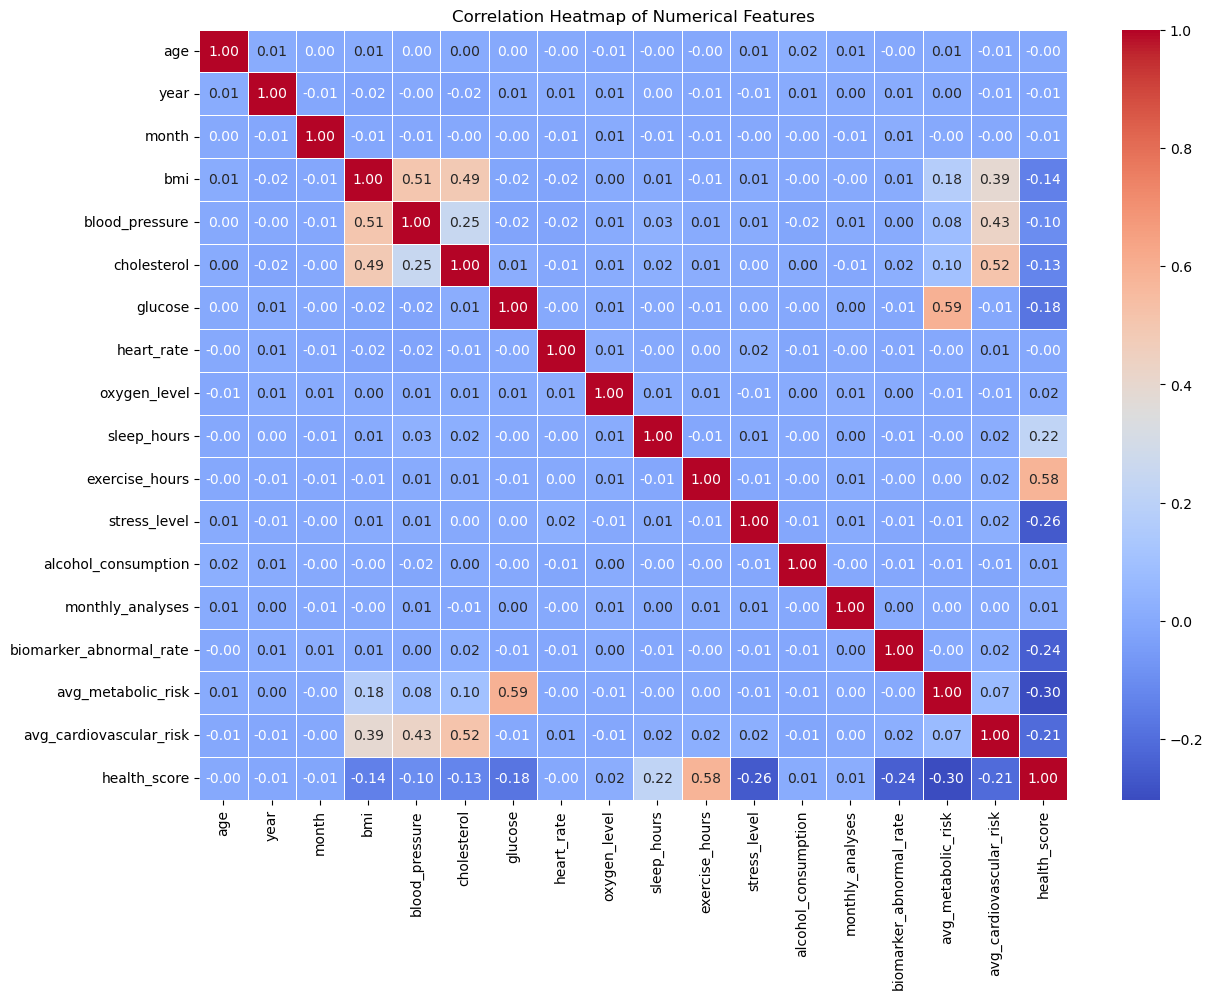

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

Correlation analysis revealed several moderate relationships among the numerical features. BMI showed moderate positive correlations with blood pressure (r = 0.506) and cholesterol (r = 0.487). Cholesterol was also moderately correlated with average cardiovascular risk (r = 0.516), while glucose showed a moderate positive correlation with average metabolic risk (r = 0.589). Exercise hours had the strongest positive correlation with health score (r = 0.583), whereas stress level showed a weak negative relationship with health score (r = -0.259). Average metabolic risk and biomarker abnormal rate also showed negative relationships with health score. Most remaining feature pairs had weak correlations, indicating limited linear relationships among those variables.

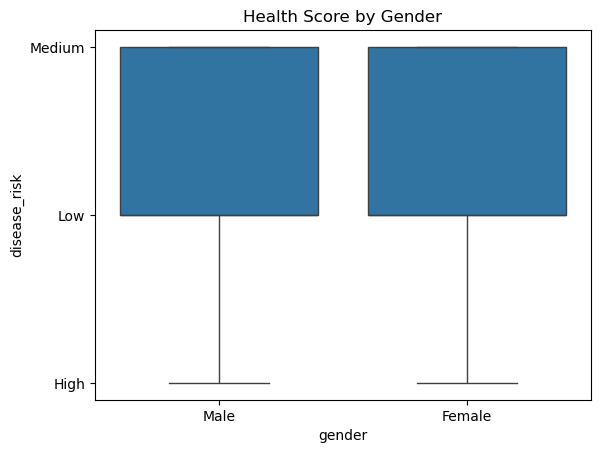

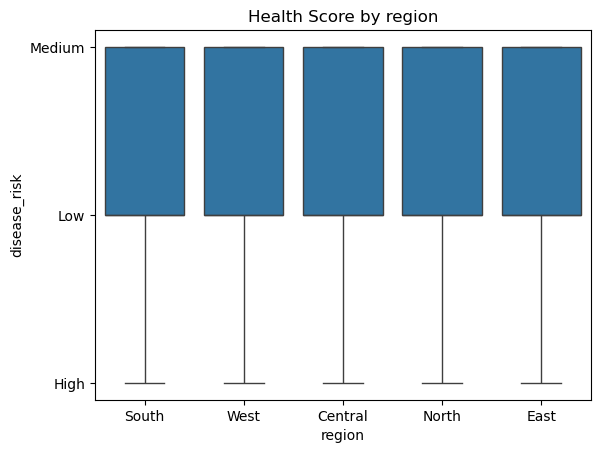

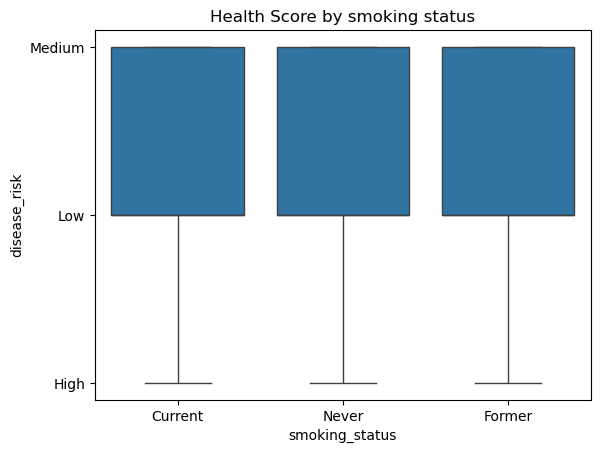

In [23]:
sns.boxplot(
    data=df,
    x='gender',
    y=target
)

plt.title('Health Score by Gender')
plt.show()

sns.boxplot(
    data=df,
    x='region',
    y=target
)

plt.title('Health Score by region')
plt.show()

sns.boxplot(
    data=df,
    x='smoking_status',
    y=target
)

plt.title('Health Score by smoking status')
plt.show()

It shows that majority disease risk lies between Low and Medium risk and very small percentage in higher risk

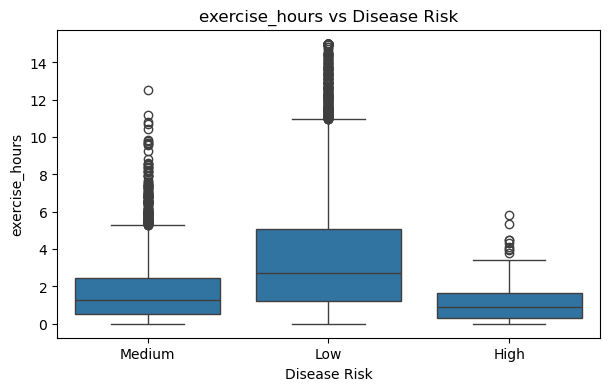

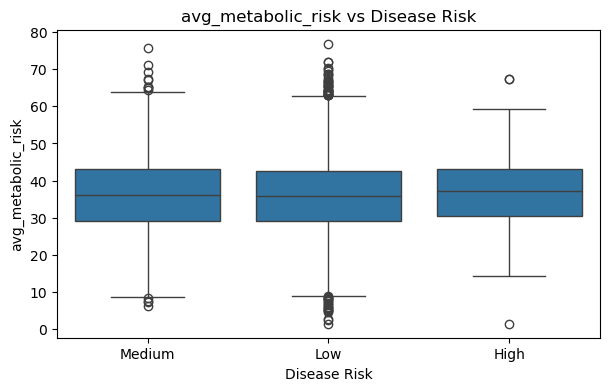

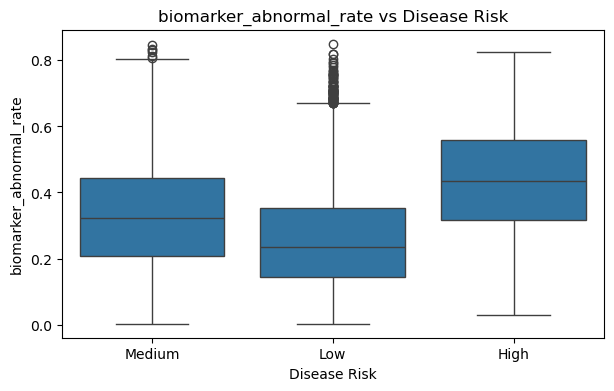

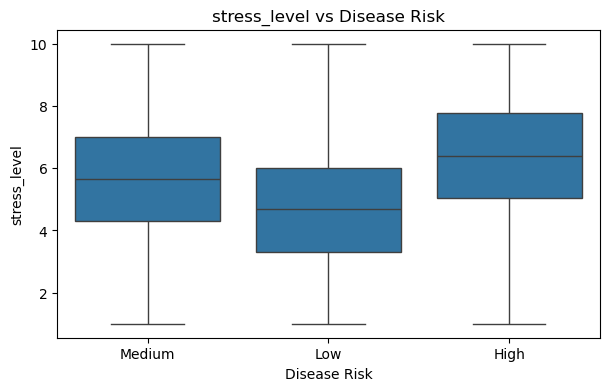

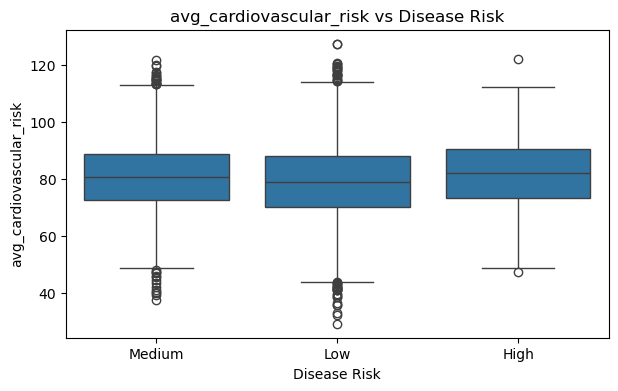

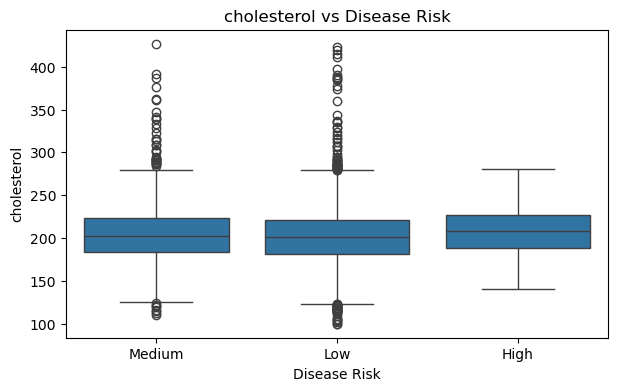

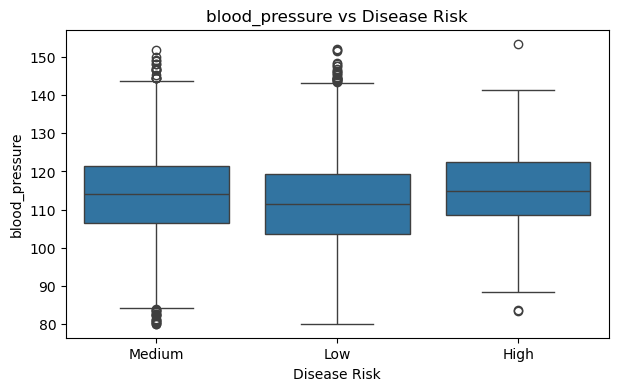

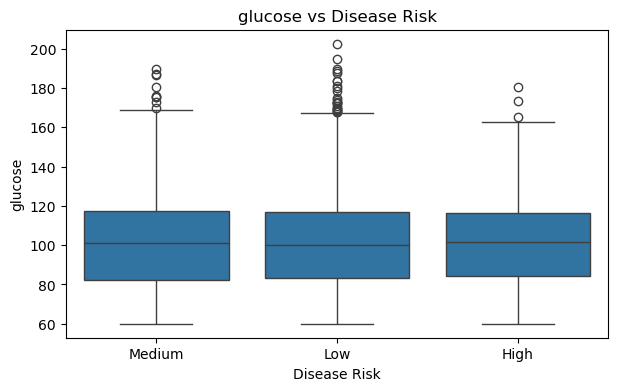

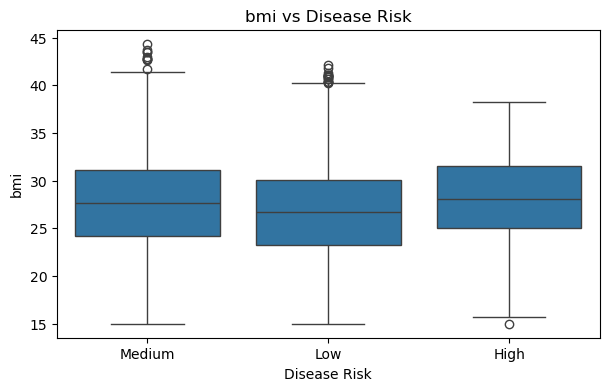

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

important_features = [
    'exercise_hours',
    'avg_metabolic_risk',
    'biomarker_abnormal_rate',
    'stress_level',
    'avg_cardiovascular_risk',
    'cholesterol',
    'blood_pressure',
    'glucose',
    'bmi'
]

for col in important_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x='disease_risk', y=col)
    plt.title(f'{col} vs Disease Risk')
    plt.xlabel('Disease Risk')
    plt.ylabel(col)
    plt.show()

Feature-vs-target analysis indicates that exercise hours, biomarker abnormal rate, and stress level show noticeable relationships with disease risk. Patients with higher exercise hours tend to have lower disease-risk levels, whereas higher biomarker abnormal rates and stress levels are associated with higher disease risk. These features may therefore provide useful predictive information for the classification models.

The boxplot analysis shows differences in the distributions of several numerical features across disease-risk categories. Exercise hours show a relatively wider IQR in the low-risk group, indicating greater variability in exercise levels among these patients. In contrast, stress level and biomarker abnormal rate show higher values in the higher disease-risk groups, suggesting an association with increased disease risk. Several other numerical features have relatively similar IQRs across the disease-risk categories, indicating comparable within-group variability.

## EDA Conclusion

The exploratory data analysis provided several useful insights into the dataset and the factors associated with disease risk. The target variable was found to be imbalanced, with the low disease-risk class representing a larger proportion of observations than the medium- and high-risk classes. Some categorical variables, particularly smoking status, showed noticeable differences in disease-risk distribution, while gender and region showed relatively similar distributions across the risk categories.

The numerical analysis revealed varying distributions and levels of skewness among the features. Outlier analysis identified potential extreme observations, while correlation analysis showed several moderate relationships between features. For example, BMI was moderately correlated with blood pressure and cholesterol, glucose was correlated with average metabolic risk, and cholesterol was correlated with average cardiovascular risk.

Feature-versus-target analysis suggested that exercise hours, stress level, and biomarker abnormal rate may provide useful information for distinguishing disease-risk categories. Higher exercise levels appeared more frequently in lower-risk groups, while higher stress levels and abnormal biomarker rates were associated with higher disease-risk groups.

Overall, the EDA indicates that the dataset contains meaningful patterns that can be used for classification. However, because the target classes are imbalanced, model evaluation should consider metrics such as precision, recall, F1-score, and the confusion matrix rather than relying only on accuracy.

The dataset is now ready for the next stage: **train/test splitting, preprocessing, and classification using a Pipeline and ColumnTransformer**.


In [25]:
X = df.drop('disease_risk', axis=1)
y = df['disease_risk']

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

print("Numerical features:")
print(list(numeric_features))

print("\nCategorical features:")
print(list(categorical_features))

Numerical features:
['patient_id', 'age', 'year', 'month', 'bmi', 'blood_pressure', 'cholesterol', 'glucose', 'heart_rate', 'oxygen_level', 'sleep_hours', 'exercise_hours', 'stress_level', 'alcohol_consumption', 'monthly_analyses', 'biomarker_abnormal_rate', 'avg_metabolic_risk', 'avg_cardiovascular_risk', 'health_score']

Categorical features:
['gender', 'region', 'smoking_status']


In [26]:
X = X.drop(['patient_id', 'date'], axis=1, errors='ignore')

In [27]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

Outliers were identified during exploratory analysis but were not automatically removed because extreme health measurements may represent genuine patient conditions and can contain important information for disease-risk classification. Therefore, the original observations were retained unless an observation was determined to be an obvious data-entry or measurement error.

# Model Selection and Evaluation

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (9600, 21)
X_test: (2400, 21)
y_train: (9600,)
y_test: (2400,)


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [31]:
y_pred = logistic_pipeline.predict(X_test)

print(y_pred[:10])

['Medium' 'Low' 'Low' 'Low' 'Low' 'Medium' 'Low' 'Low' 'Low' 'Low']


In [32]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7333333333333333

Classification Report:
              precision    recall  f1-score   support

        High       0.44      0.07      0.12        59
         Low       0.77      0.89      0.83      1596
      Medium       0.61      0.45      0.52       745

    accuracy                           0.73      2400
   macro avg       0.61      0.47      0.49      2400
weighted avg       0.71      0.73      0.71      2400


Confusion Matrix:
[[   4   13   42]
 [   0 1419  177]
 [   5  403  337]]


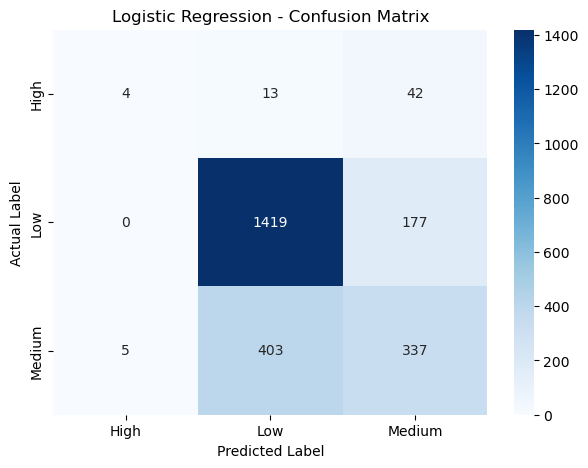

In [33]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['High', 'Low', 'Medium'],
    yticklabels=['High', 'Low', 'Medium']
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Logistic Regression - Confusion Matrix')

plt.show()

The Logistic Regression model achieved an overall accuracy of 73.33%. However, the class-wise evaluation revealed significant differences in performance due to the imbalanced target distribution. The model performed well for the Low-risk class, achieving a recall of 0.89 and an F1-score of 0.83. Performance on the Medium-risk class was moderate, with a recall of 0.45 and an F1-score of 0.52. However, the High-risk class was poorly detected, with a recall of only 0.07 and an F1-score of 0.12. The confusion matrix shows that most High-risk observations were incorrectly classified as Medium-risk. Therefore, despite the relatively high overall accuracy, the Logistic Regression model is not sufficiently reliable for identifying high-risk cases.

In [34]:
balanced_logistic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

balanced_logistic_pipeline.fit(X_train, y_train)
y_pred_balanced = balanced_logistic_pipeline.predict(X_test)

In [35]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_pred_balanced))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced))

Accuracy: 0.6391666666666667

Classification Report:
              precision    recall  f1-score   support

        High       0.10      0.54      0.17        59
         Low       0.86      0.72      0.78      1596
      Medium       0.47      0.48      0.47       745

    accuracy                           0.64      2400
   macro avg       0.48      0.58      0.48      2400
weighted avg       0.72      0.64      0.67      2400


Confusion Matrix:
[[  32    3   24]
 [  76 1146  374]
 [ 200  189  356]]


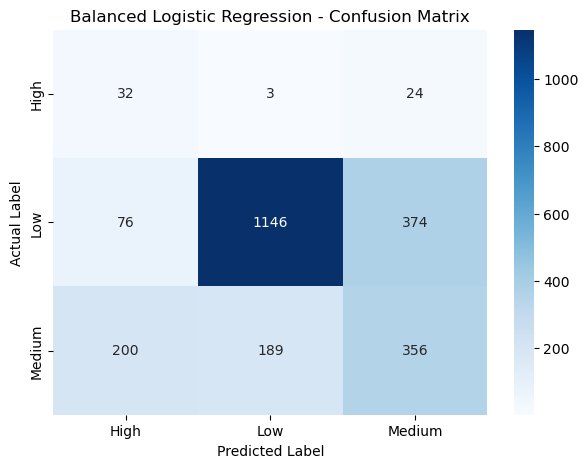

In [36]:
cm_balanced = confusion_matrix(y_test, y_pred_balanced)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_balanced,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['High', 'Low', 'Medium'],
    yticklabels=['High', 'Low', 'Medium']
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Balanced Logistic Regression - Confusion Matrix')

plt.show()

The confusion matrix clearly shows that the balanced model substantially improves High-risk detection. Out of 59 actual High-risk cases, 32 were correctly classified, while 24 were classified as Medium and only 3 as Low. This corresponds to the improved High-risk recall of 54%, compared with only 7% for the original Logistic Regression model.

However, the model also produces more false High-risk predictions. In particular, 76 Low-risk and 200 Medium-risk cases were incorrectly classified as High-risk. This explains the relatively low High-risk precision of 10%.

The model therefore makes a clear trade-off: it sacrifices overall accuracy (73.33% → 63.92%) to substantially improve detection of the minority High-risk class. For a health-risk classification problem, this trade-off can be important because failing to identify a genuinely high-risk case may be more concerning than incorrectly flagging some lower-risk cases

In [50]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(label_encoder.classes_)

['High' 'Low' 'Medium']


In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'
    ))
])

In [38]:
dt_pipeline.fit(X_train, y_train)
y_pred_dt = dt_pipeline.predict(X_test)

In [39]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Accuracy: 0.6308333333333334

Classification Report:
              precision    recall  f1-score   support

        High       0.06      0.05      0.05        59
         Low       0.74      0.75      0.74      1596
      Medium       0.43      0.42      0.43       745

    accuracy                           0.63      2400
   macro avg       0.41      0.41      0.41      2400
weighted avg       0.63      0.63      0.63      2400


Confusion Matrix:
[[   3   29   27]
 [  17 1200  379]
 [  31  403  311]]


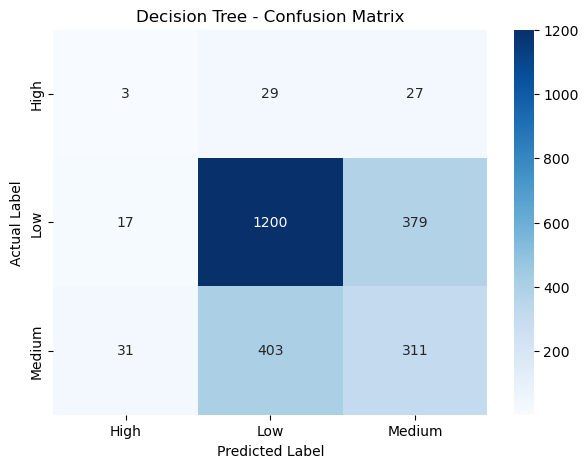

In [40]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['High', 'Low', 'Medium'],
    yticklabels=['High', 'Low', 'Medium']
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Decision Tree - Confusion Matrix')

plt.show()

The balanced Decision Tree achieved an accuracy of 63.08%, which is slightly lower than the balanced Logistic Regression model. More importantly, its performance on the minority High-risk class was poor, with a recall of only 0.05 and an F1-score of 0.05. The confusion matrix shows that only 3 of the 59 High-risk cases were correctly identified, while most were classified as Low or Medium. Although the model performed reasonably on the Low-risk class, its inability to detect High-risk observations makes it unsuitable as the preferred model at this stage.

In [41]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

In [42]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.7133333333333334

Classification Report:
              precision    recall  f1-score   support

        High       0.00      0.00      0.00        59
         Low       0.73      0.93      0.82      1596
      Medium       0.60      0.30      0.40       745

    accuracy                           0.71      2400
   macro avg       0.45      0.41      0.41      2400
weighted avg       0.68      0.71      0.67      2400


Confusion Matrix:
[[   0   20   39]
 [   0 1490  106]
 [   1  522  222]]


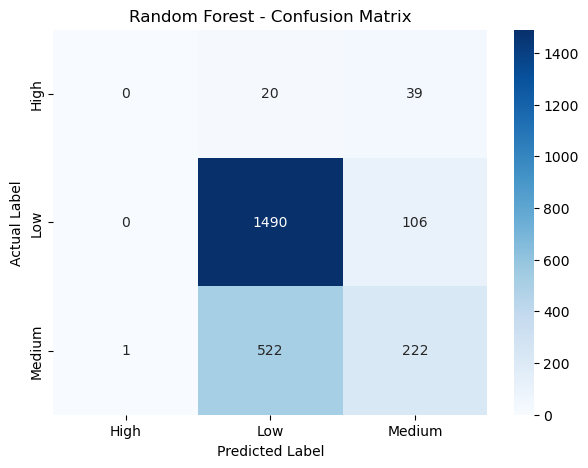

In [43]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['High', 'Low', 'Medium'],
    yticklabels=['High', 'Low', 'Medium']
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Random Forest - Confusion Matrix')

plt.show()

The Random Forest classifier achieved an overall accuracy of 71.33%, but its class-wise performance revealed a serious limitation. The model achieved a high recall of 0.93 for the Low-risk class but failed to identify any of the 59 High-risk observations, resulting in a High-risk recall and F1-score of 0.00. The confusion matrix confirms that all High-risk cases were misclassified as either Low or Medium. Therefore, despite its relatively high accuracy, the Random Forest model is not suitable for the current disease-risk classification objective because it fails to detect the minority High-risk class.

In [45]:
from sklearn.ensemble import GradientBoostingClassifier

gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

gb_pipeline.fit(X_train, y_train)
y_pred_gb = gb_pipeline.predict(X_test)

In [46]:
print("Accuracy:", accuracy_score(y_test, y_pred_gb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

Accuracy: 0.73125

Classification Report:
              precision    recall  f1-score   support

        High       0.25      0.03      0.06        59
         Low       0.77      0.88      0.83      1596
      Medium       0.60      0.46      0.52       745

    accuracy                           0.73      2400
   macro avg       0.54      0.46      0.47      2400
weighted avg       0.71      0.73      0.71      2400


Confusion Matrix:
[[   2   13   44]
 [   0 1412  184]
 [   6  398  341]]


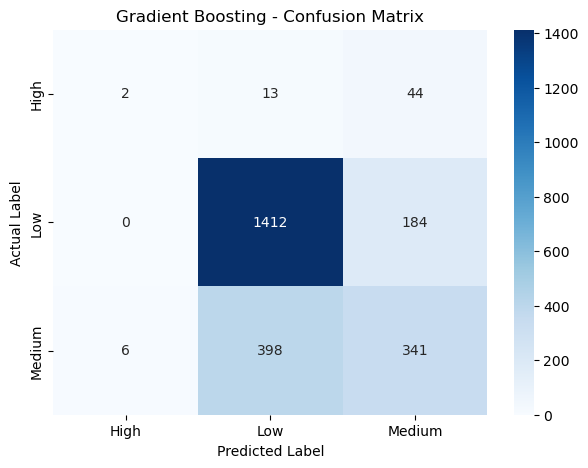

In [47]:
cm_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_gb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['High', 'Low', 'Medium'],
    yticklabels=['High', 'Low', 'Medium']
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Gradient Boosting - Confusion Matrix')

plt.show()

The Gradient Boosting classifier achieved an accuracy of 73.13%, with strong performance on the Low-risk class (recall = 0.88, F1-score = 0.83) and moderate performance on the Medium-risk class (recall = 0.46, F1-score = 0.52). However, the model performed poorly on the minority High-risk class, correctly identifying only 2 of 59 High-risk observations, resulting in a recall of 0.03 and an F1-score of 0.06. The confusion matrix shows that most High-risk cases were classified as Medium. Therefore, although Gradient Boosting provides relatively high overall accuracy, it is not effective at identifying High-risk patients in its current configuration.

In [52]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        eval_metric='mlogloss',
        n_jobs=-1
    ))
])

xgb_pipeline.fit(X_train, y_train)
y_pred_xgb = xgb_pipeline.predict(X_test)

y_test_labels = label_encoder.inverse_transform(y_test)
y_pred_xgb_labels = label_encoder.inverse_transform(y_pred_xgb)

In [53]:
print("Accuracy:", accuracy_score(y_test_labels, y_pred_xgb_labels))

print("\nClassification Report:")
print(classification_report(
    y_test_labels,
    y_pred_xgb_labels
))

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test_labels,
    y_pred_xgb_labels
))

Accuracy: 0.7370833333333333

Classification Report:
              precision    recall  f1-score   support

        High       0.25      0.03      0.06        59
         Low       0.78      0.89      0.83      1596
      Medium       0.61      0.48      0.53       745

    accuracy                           0.74      2400
   macro avg       0.55      0.46      0.47      2400
weighted avg       0.71      0.74      0.72      2400


Confusion Matrix:
[[   2    9   48]
 [   0 1413  183]
 [   6  385  354]]


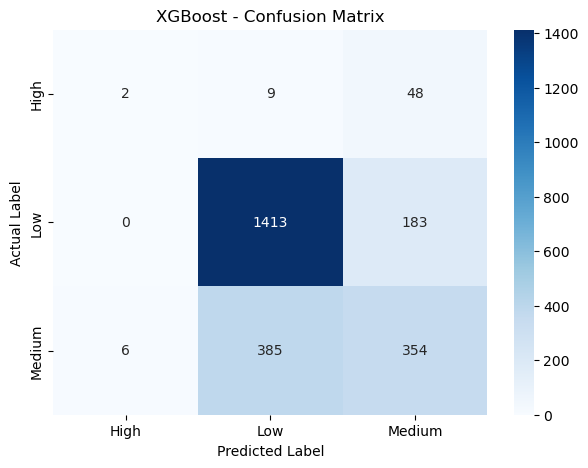

In [57]:
cm_xgb = confusion_matrix(y_test_labels, y_pred_xgb_labels)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['High', 'Low', 'Medium'],
    yticklabels=['High', 'Low', 'Medium']
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('XGBoost - Confusion Matrix')

plt.show()

In [55]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


smote_lr_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(
        random_state=42
    )),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

smote_lr_pipeline.fit(X_train, y_train)
y_pred_smote = smote_lr_pipeline.predict(X_test)

In [56]:
print("Accuracy:", accuracy_score(y_test, y_pred_smote))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_smote,
    target_names=label_encoder.classes_
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_smote))

Accuracy: 0.6420833333333333

Classification Report:
              precision    recall  f1-score   support

        High       0.11      0.54      0.18        59
         Low       0.85      0.72      0.78      1596
      Medium       0.47      0.48      0.48       745

    accuracy                           0.64      2400
   macro avg       0.48      0.58      0.48      2400
weighted avg       0.71      0.64      0.67      2400


Confusion Matrix:
[[  32    3   24]
 [  70 1152  374]
 [ 187  201  357]]


In [58]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Balanced Logistic Regression',
        'Decision Tree','Random Forest',
        'Gradient Boosting','XGBoost',
        'SMOTE Logistic Regression'
    ],
    
    'Accuracy': [
        0.7333,0.6392,0.6308,0.7133,
        0.7313,0.7371,0.6421
    ],
    
    'Macro Precision': [
        0.61,0.48,0.41,0.45,
        0.54,0.55,0.48
    ],
    
    'Macro Recall': [
        0.47,0.58,0.41,
        0.41,0.46,0.46,
        0.58
    ],
    
    'Macro F1': [
        0.49,0.48,0.41,0.41,
        0.47,0.47,0.48
    ],
    
    'High Recall': [
        0.07,0.54,0.05,0.00,
        0.03,0.03,0.54
    ],
    
    'High F1': [
        0.12,0.17, 0.05,
        0.00,0.06,0.06,
        0.18
    ]
})

print(results)

                          Model  Accuracy  Macro Precision  Macro Recall  \
0           Logistic Regression    0.7333             0.61          0.47   
1  Balanced Logistic Regression    0.6392             0.48          0.58   
2                 Decision Tree    0.6308             0.41          0.41   
3                 Random Forest    0.7133             0.45          0.41   
4             Gradient Boosting    0.7313             0.54          0.46   
5                       XGBoost    0.7371             0.55          0.46   
6     SMOTE Logistic Regression    0.6421             0.48          0.58   

   Macro F1  High Recall  High F1  
0      0.49         0.07     0.12  
1      0.48         0.54     0.17  
2      0.41         0.05     0.05  
3      0.41         0.00     0.00  
4      0.47         0.03     0.06  
5      0.47         0.03     0.06  
6      0.48         0.54     0.18  


Based on the comparative evaluation, XGBoost achieved the highest overall accuracy of 73.71%; however, it demonstrated very poor performance on the minority High-risk class, with only 3% recall. SMOTE Logistic Regression achieved a lower overall accuracy of 64.21% but substantially improved High-risk detection, achieving 54% recall and the highest High-risk F1-score of 0.18. Considering the importance of identifying high-risk cases in the health-risk classification problem, SMOTE Logistic Regression is currently the more appropriate model despite its lower overall accuracy.

In [59]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    smote_lr_pipeline,
    X_test,
    y_test,
    scoring='f1_macro',
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

feature_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': perm.importances_mean
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                    Feature  Importance
12           exercise_hours    0.060189
13             stress_level    0.051004
17  biomarker_abnormal_rate    0.042443
0                       age    0.033277
6            blood_pressure    0.004036
20             health_score    0.004008
10             oxygen_level    0.001805
8                   glucose    0.001332
14           smoking_status    0.001203
5                       bmi    0.001061
3                      year    0.000974
7               cholesterol    0.000882
1                    gender    0.000750
2                    region   -0.000258
16         monthly_analyses   -0.000325
18       avg_metabolic_risk   -0.000382
4                     month   -0.000737
11              sleep_hours   -0.001269
9                heart_rate   -0.001437
19  avg_cardiovascular_risk   -0.001820
15      alcohol_consumption   -0.001958


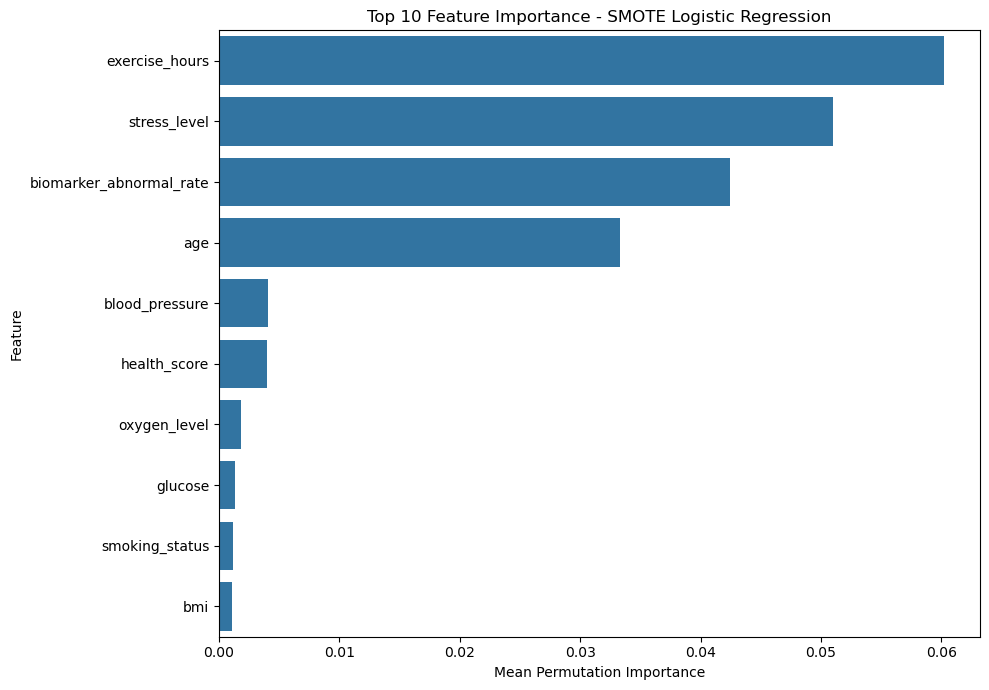

In [60]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Feature Importance - SMOTE Logistic Regression')
plt.xlabel('Mean Permutation Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

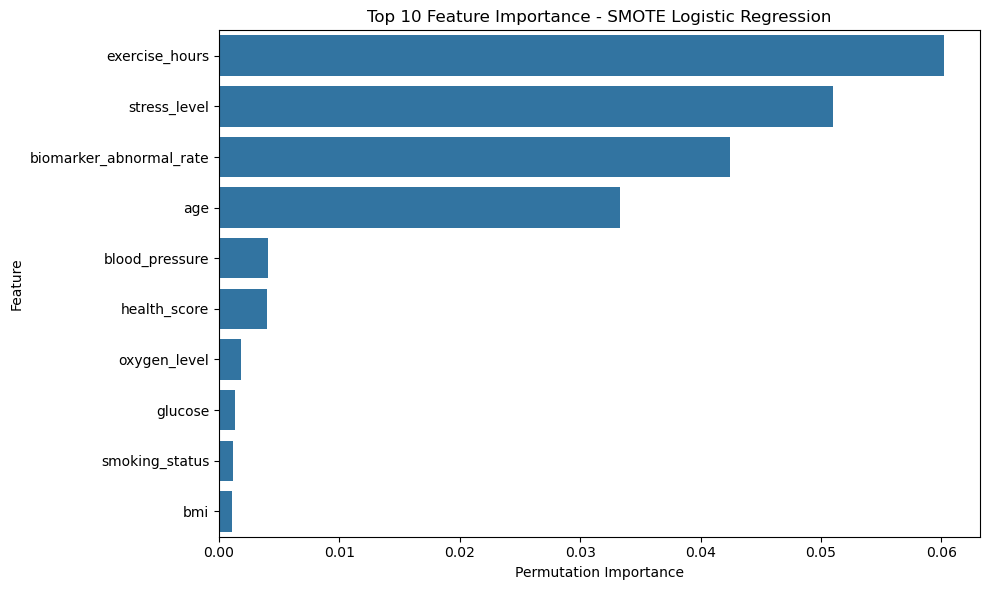

In [61]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Feature Importance - SMOTE Logistic Regression')
plt.xlabel('Permutation Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

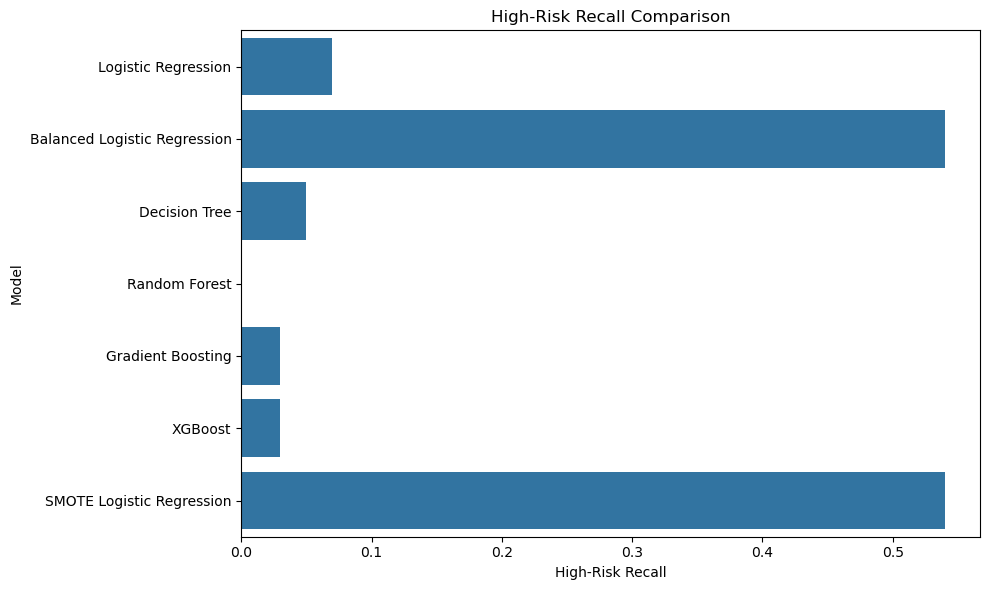

In [62]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results,
    x='High Recall',
    y='Model'
)

plt.title('High-Risk Recall Comparison')
plt.xlabel('High-Risk Recall')
plt.ylabel('Model')

plt.tight_layout()
plt.show()

XGBoost had the highest accuracy (73.71%), but SMOTE Logistic Regression was selected because it achieved substantially better High-risk detection (54% recall).

Permutation importance showed that exercise hours was the most influential feature in the final model, followed by stress level, biomarker abnormal rate, and age. These features contributed substantially more to the model's predictive performance than the remaining variables. Several features, including region, monthly analyses, month, sleep hours, heart rate, cardiovascular risk, and alcohol consumption, had near-zero or slightly negative permutation importance, indicating limited additional predictive contribution in the final model. These importance values represent predictive contribution to the model and should not be interpreted as causal relationships

# Conclusion

This project developed a machine learning classification system for predicting disease-risk categories using demographic, lifestyle, physiological, and health-related features. The dataset was first examined through data inspection and exploratory data analysis, including missing-value analysis, outlier detection, skewness analysis, categorical analysis, numerical feature analysis, and correlation analysis.

The analysis revealed a significant class imbalance, with Low-risk observations substantially outnumbering Medium- and High-risk observations. This imbalance had a major effect on model performance. Initial Logistic Regression achieved an accuracy of 73.33%, but its recall for the High-risk class was only 7%, demonstrating that accuracy alone was not an appropriate metric for evaluating this problem.

Several classification algorithms were subsequently evaluated, including Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, and XGBoost. XGBoost achieved the highest overall accuracy of 73.71%, but its High-risk recall was only 3%. Therefore, the highest-accuracy model was not necessarily the most suitable model for the project's objective.

Class balancing was then investigated using class_weight='balanced' and SMOTE. SMOTE Logistic Regression achieved an accuracy of 64.21%, while substantially improving High-risk detection to 54% recall and 0.18 F1-score. It correctly identified 32 of the 59 High-risk observations, compared with only 2 identified by XGBoost. Therefore, SMOTE Logistic Regression was selected as the preferred model because identifying High-risk cases was considered more important than maximizing overall accuracy.

Feature importance analysis was also performed using permutation importance to identify which features contributed most to the model's predictive performance. These results provide additional insight into the factors that the model relied on when making disease-risk predictions.

Overall, the project demonstrates that model selection should be based on the objective of the problem rather than accuracy alone, particularly when dealing with imbalanced health-related classification data. The use of preprocessing pipelines, class balancing, SMOTE, multiple classification algorithms, confusion matrices, and class-specific evaluation metrics resulted in a more reliable and comprehensive machine learning workflow.